# Modelación en ingeniería
## Cálculo de curva de linealidad

*Profesor: David Ortiz-Puerta*

---

### Introducción

En los sistemas clásicos $\dot{x} = f(x, u)$, la entrada $u$ es explícita y la *curva de linealidad* se construye barriendo valores de $u$ y registrando la salida estacionaria $y_{ss}$, asumiendo que el sistema converge a un punto de equilibrio.

Muchos sistemas, sin embargo, son autónomos $\dot{x} = f(x)$. Esto no impide el análisis: parámetros físicamente manipulables dentro de $f$ pueden reinterpretarse como entradas, $u = p$.

Cuando la respuesta estacionaria no es un punto fijo sino un ciclo o atractor, $y_{ss}$ deja de existir como valor único. En su lugar, se caracteriza la respuesta mediante un descriptor escalar (amplitud, centro) y se estudia su variación con $u$. Si la relación descriptor–entrada es lineal en un rango, el sistema exhibe linealidad de respuesta global en ese rango, sin importar el régimen interno.

> **💡 IMPORTANTE**
>
> Los puntos de equilibrio también pueden tomarse como puntos de operación y realizar la linealización centrada en este

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from helpers import (configure_plot_style)

configure_plot_style()

## Sistema de Lorenz

Modelo tridimensional autónomo propuesto por Edward Lorenz (1963) como simplificación de la convección atmosférica. Pese a su forma compacta, exhibe una rica variedad de regímenes —punto fijo estable, ciclos y caos determinista— al variar sus parámetros, lo que lo convierte en un caso de estudio estándar para análisis no lineal.

$$
\begin{aligned}
\dot{x} &= \sigma (y - x) \\
\dot{y} &= u\,x - y - x z \\
\dot{z} &= x y - \beta z
\end{aligned}
$$

Parámetros fijos: $\sigma = 10$, $\beta = 8/3$.

Condiciones iniciales: $x(0) = 10$, $y(0) = 7$, $z(0) = 7$.

Entrada del sistema: $u = \rho$, tratada como variable manipulable cuyo valor define el régimen de operación.

In [7]:
sigma, beta = 10.0, 8/3

def lorenz(x, y, z, u):
    dx = sigma * (y - x)
    dy = u * x - y - x * z
    dz = x * y - beta * z
    return dx, dy, dz

def rk4_step(x, y, z, u, dt):
    k1 = lorenz(x, y, z, u)
    k2 = lorenz(x + dt*k1[0]/2, y + dt*k1[1]/2, z + dt*k1[2]/2, u)
    k3 = lorenz(x + dt*k2[0]/2, y + dt*k2[1]/2, z + dt*k2[2]/2, u)
    k4 = lorenz(x + dt*k3[0],   y + dt*k3[1],   z + dt*k3[2],   u)
    return (x + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            y + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            z + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]))

### Método

Se barre la entrada $u$ sobre un rango de valores. Para cada $u$ se integra el sistema en paralelo con una condición inicial común, descartando un transitorio inicial para que la trayectoria alcance su régimen permanente.

Una vez en régimen, se registran los valores máximo y mínimo de cada variable de estado a lo largo de una ventana de análisis. A partir de ellos se construyen dos descriptores escalares por variable:

$$
\text{amplitud} = \frac{x_{\max} - x_{\min}}{2}, \qquad \text{centro} = \frac{x_{\max} + x_{\min}}{2}
$$

La amplitud caracteriza el tamaño de la oscilación estacionaria; vale cero cuando el sistema converge a un punto fijo. El centro indica en torno a qué valor oscila la trayectoria.

Graficar amplitud y centro frente a $u$ revela la curva de linealidad generalizada: los tramos donde estos descriptores varían linealmente con $u$ delimitan el rango de linealidad de respuesta global del sistema.

In [14]:
u_vals = np.arange(0.0, 2000.0 + 1, 0.1)
dt = 0.001
t_trans, t_anal = 40.0, 10.0

x = np.full(len(u_vals), 10.0)
y = np.full(len(u_vals), 7.0)
z = np.full(len(u_vals), 7.0)

# Transitorio
for _ in range(int(t_trans / dt)):
    x, y, z = rk4_step(x, y, z, u_vals, dt)

# Régimen permanente: amplitud (min/max) y media temporal
xmax, xmin = x.copy(), x.copy()
ymax, ymin = y.copy(), y.copy()
zmax, zmin = z.copy(), z.copy()

x_sum = np.zeros(len(u_vals))
y_sum = np.zeros(len(u_vals))
z_sum = np.zeros(len(u_vals))

N = int(t_anal / dt)
for _ in range(N):
    x, y, z = rk4_step(x, y, z, u_vals, dt)
    np.maximum(xmax, x, out=xmax); np.minimum(xmin, x, out=xmin)
    np.maximum(ymax, y, out=ymax); np.minimum(ymin, y, out=ymin)
    np.maximum(zmax, z, out=zmax); np.minimum(zmin, z, out=zmin)
    x_sum += x; y_sum += y; z_sum += z

X_amp = (xmax - xmin) / 2
Y_amp = (ymax - ymin) / 2
Z_amp = (zmax - zmin) / 2

X_mid = x_sum / N
Y_mid = y_sum / N
Z_mid = z_sum / N


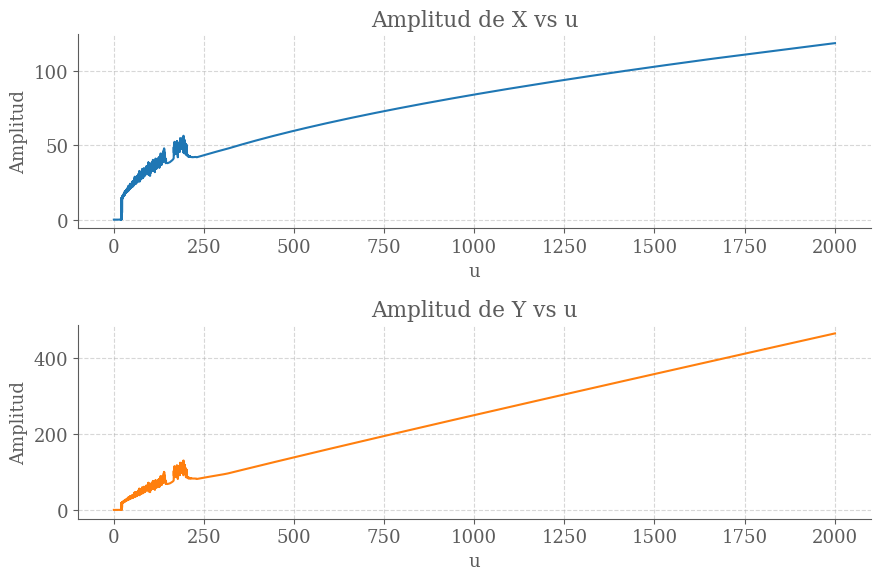

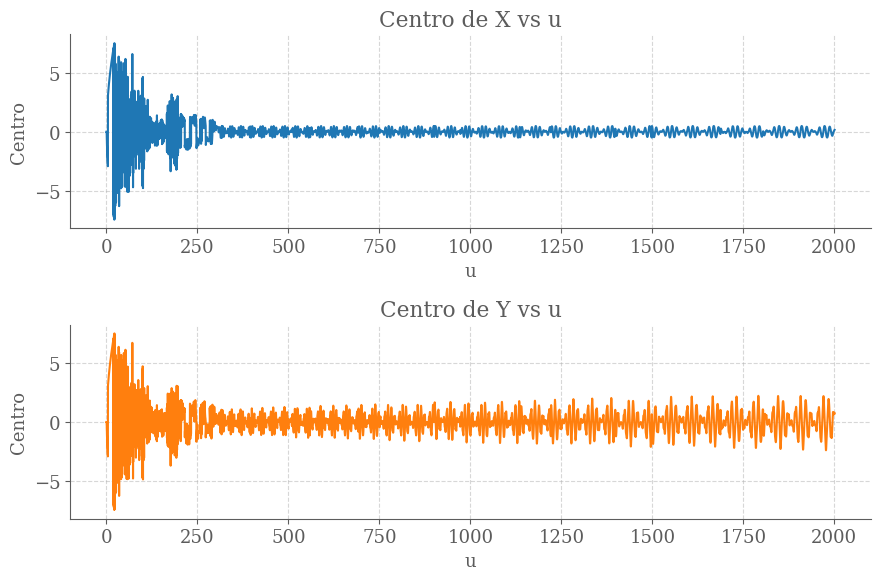

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(9, 6))

axs[0].plot(u_vals, X_amp, color='tab:blue')
axs[0].set_title('Amplitud de X vs u')
axs[0].set_xlabel('u'); axs[0].set_ylabel('Amplitud')

axs[1].plot(u_vals, Y_amp, color='tab:orange')
axs[1].set_title('Amplitud de Y vs u')
axs[1].set_xlabel('u'); axs[1].set_ylabel('Amplitud')



for ax in axs.flat:
    ax.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


fig, axs = plt.subplots(2, 1, figsize=(9, 6))

axs[0].plot(u_vals, X_mid, color='tab:blue')
axs[0].set_title('Centro de X vs u')
axs[0].set_xlabel('u'); axs[0].set_ylabel('Centro')

axs[1].plot(u_vals, Y_mid, color='tab:orange')
axs[1].set_title('Centro de Y vs u')
axs[1].set_xlabel('u'); axs[1].set_ylabel('Centro')


for ax in axs.flat:
    ax.grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

De las gráficas podemos observar que al rededor de la entrada $u_0 = 155$, el sistema se comporta de forma lineal. Así seleccionamos este punto de operación, y calculamos el punto de operación $x_0$:

In [10]:
u0 = 155.0
idx = np.argmin(np.abs(u_vals - u0))
x0, y0, z0 = X_mid[idx], Y_mid[idx], Z_mid[idx]
print(f"x0={x0:.4f}, y0={y0:.4f}, z0={z0:.4f}")

x0=-0.0057, y0=-0.0078, z0=155.1356


## Selección del punto de operación y linealización

En los gráficos de amplitud y centro se observa que, en torno a $u_0 \approx 150\text{–}160$, los descriptores presentan un tramo relativamente suave y aproximadamente lineal respecto a la entrada. Ese intervalo define un **rango de linealidad** utilizable: dentro de él, pequeñas variaciones de $u$ producen variaciones proporcionales en la respuesta estacionaria. Tomamos entonces $u_0$ en ese rango como **punto de operación** y linealizamos el sistema a su alrededor.

### Variables incrementales

La linealización describe el sistema no en términos absolutos, sino como desviaciones respecto al punto de operación $(x_0, u_0)$:

$$
\Delta x = x - x_0, \qquad \Delta u = u - u_0, \qquad \Delta y = y - y_0
$$

La salida reconstruida del modelo linealizado es $\hat{y} = y_0 + \Delta y$, como ilustra el diagrama: la entrada $u$ se descompone en $u_0 + \Delta u$, el modelo lineal procesa solo $\Delta u$, y la salida se reensambla sumando $y_0$.

### Cálculo del punto de operación

Para $u_0 = 155$, el sistema no converge a un punto fijo sino a un atractor oscilante. El punto de operación se define a partir de los **descriptores del régimen estacionario** obtenidos en el barrido anterior:

$$
x_0 \approx -0.006, \qquad y_0 \approx -0.008, \qquad z_0 \approx 155.14
$$

### Construcción del modelo lineal: Jacobianos

Sean las variables de desviación $\Delta x_i = x_i - x_{i,0}$. Linealizando el sistema alrededor de $(x_0, y_0, z_0)$ se obtiene:

$$
\Delta\dot{x} = -\sigma\,\Delta x + \sigma\,\Delta y
$$
$$
\Delta\dot{y} = (u_0 - z_0)\,\Delta x - \Delta y - x_0\,\Delta z + x_0\,\Delta u
$$
$$
\Delta\dot{z} = y_0\,\Delta x + x_0\,\Delta y - \beta\,\Delta z
$$

En forma matricial:

$$
\begin{bmatrix} \Delta\dot{x} \\ \Delta\dot{y} \\ \Delta\dot{z} \end{bmatrix}
=
\underbrace{\begin{bmatrix} -\sigma & \sigma & 0 \\ u_0 - z_0 & -1 & -x_0 \\ y_0 & x_0 & -\beta \end{bmatrix}}_{A}
\begin{bmatrix} \Delta x \\ \Delta y \\ \Delta z \end{bmatrix}
+
\underbrace{\begin{bmatrix} 0 \\ x_0 \\ 0 \end{bmatrix}}_{B}
\Delta u
$$

Evaluando en el punto de operación $u_0 = 155$, $x_0 \approx -0.006$, $y_0 \approx -0.008$, $z_0 \approx 155.14$:

$$
A =
\begin{bmatrix}
-10 & 10 & 0 \\
-0.14 & -1 & 0.006 \\
-0.008 & -0.006 & -2.67
\end{bmatrix},
\qquad
B =
\begin{bmatrix}
0 \\ -0.006 \\ 0
\end{bmatrix}
$$


### Validez local

El modelo linealizado es una aproximación válida **solo en una vecindad de $(x_0, u_0)$**: mientras $\|\Delta x\|$ y $|\Delta u|$ permanezcan pequeños, el comportamiento de $\hat{y}$ replica al del sistema no lineal. Fuera de esa vecindad, los términos de orden superior descartados en Taylor dominan y la aproximación pierde validez.

## Validación: modelo no lineal vs linealizado

Para verificar la calidad de la linealización, se comparan ambos modelos ante una misma entrada $u = u_0 + \Delta u$:

- **Modelo no lineal**: se integra $\dot{x} = f(x, u)$ con condición inicial $x(0) = x_0$.
- **Modelo linealizado**: se integra $\Delta\dot{x} = A\Delta x + B\Delta u$ con condición inicial $\Delta x(0) = 0$, y se reconstruye $\hat{x} = x_0 + \Delta x$.

Autovalores: [-9.97547959 -2.10837037 -1.5828167 ]
Autovalores: [-9.97547959 -2.10837037 -1.5828167 ]


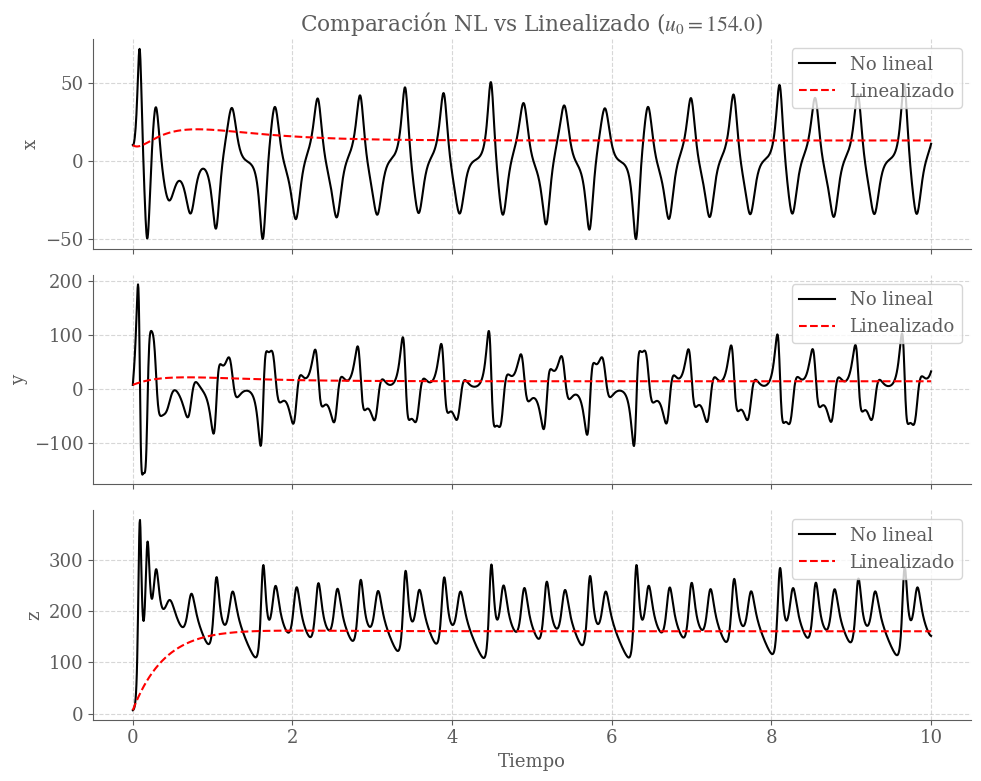

In [27]:
from scipy.integrate import solve_ivp

def simulate_lorenz(x0, t, u=155.0, x_op=None, linear=False):
    sigma, beta = 10.0, 8/3

    if x_op is None:
        idx = np.argmin(np.abs(u_vals - u0))
        x_eq, y_eq, z_eq = X_mid[idx], Y_mid[idx], Z_mid[idx]
    else:
        x_eq, y_eq, z_eq = x_op

    A = np.array([[-sigma,       sigma,    0    ],
                  [u0 - z_eq,   -1,       -x_eq ],
                  [y_eq,         x_eq,    -beta  ]])

    B = np.array([0, x_eq, 0])
    
    eigenvalues, eigenvectors = np.linalg.eig(A)
    print("Autovalores:", eigenvalues)

    if linear:
        def rhs(ti, s):
            du = u - u0
            return (A @ np.array(s) + B * du).tolist()
        x0_sim = [x0[0] - x_eq, 
                  x0[1] - y_eq, 
                  x0[2] - z_eq]
    else:
        def rhs(ti, s):
            x, y, z = s
            return [sigma*(y - x), u*x - y - x*z, x*y - beta*z]
        x0_sim = x0

    sol = solve_ivp(rhs, (t[0], t[-1]), x0_sim, t_eval=t,
                    method='RK45', rtol=1e-8, atol=1e-10)

    x, y, z = sol.y
    if linear:
        x = x + x_eq
        y = y + y_eq
        z = z + z_eq

    return x, y, z


t = np.linspace(0, 10, 2000)
x0 = [10.0, 7.0, 7.0]
u = 155

x_nl, y_nl, z_nl = simulate_lorenz(x0, t, u, linear=False)
x_li, y_li, z_li = simulate_lorenz(x0, t, u, linear=True)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, nl, li, lbl in zip(axs, [x_nl, y_nl, z_nl], [x_li, y_li, z_li], ['x','y','z']):
    ax.plot(t, nl, 'k', lw=1.5, label='No lineal')
    ax.plot(t, li, 'r--', lw=1.5, label='Linealizado')
    ax.set_ylabel(lbl)
    ax.legend(loc='upper right')
    ax.grid(True, ls='--', alpha=0.5)

axs[0].set_title(f'Comparación NL vs Linealizado ($u_0 = {u0}$)')
axs[-1].set_xlabel('Tiempo')
plt.tight_layout()
plt.show()